In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import os

In [2]:
path = 'datasets/large/utk_face/utkface_aligned_cropped/UTKFace'

In [3]:
age=[]
gender = []
img_path=[]
for file in os.listdir(path):
    age.append(int(file.split('_')[0]))
    gender.append(int(file.split('_')[1]))
    img_path.append(file)

In [4]:
print(len(age))
print(len(gender))
print(len(img_path))

23708
23708
23708


In [5]:
df = pd.DataFrame({
    'age':age,
    'gender':gender,
    'img':img_path
})

In [6]:
df.shape

(23708, 3)

In [7]:
df.sample(5)

,age,gender,img
11824,32,0,32_0_2_20170116185010991.jpg.chip.jpg
11402,31,0,31_0_4_20170117020719427.jpg.chip.jpg
6921,26,1,26_1_0_20170117201443317.jpg.chip.jpg
12163,32,1,32_1_2_20170109141342355.jpg.chip.jpg
21073,64,1,64_1_0_20170110132148994.jpg.chip.jpg


In [8]:
train_df = df.sample(frac=1,random_state=0).iloc[:20000]
test_df = df.sample(frac=1,random_state=0).iloc[20000:]

In [ ]:
# Data Augmentation
# defining generators
import tensorflow
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range = 0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(preprocess_input)

In [10]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=path,
    x_col='img',
    y_col=['age','gender'],
    target_size=(200,200),
    class_mode='multi_output'
)
test_generator = test_datagen.flow_from_dataframe(test_df,
                                                    directory=path,
                                                    x_col='img',
                                                    y_col=['age','gender'],
                                                    target_size=(200,200),
                                                  class_mode='multi_output')

Found 20000 validated image filenames.
Found 3708 validated image filenames.


In [11]:
# pretrained model
from tensorflow.keras.applications.resnet50 import ResNet50
from keras.layers import *
from keras.models import Model

In [12]:
resnet = ResNet50(
    include_top=False, #fc layers to be included -> false
    input_shape=(200,200,3)
)

In [ ]:
resnet.trainable = False #freezing

output = resnet.layers[-1].output

flatten = Flatten()(resnet.output)

dense1 = Dense(512,activation='relu')(flatten)
dense2 = Dense(512,activation='relu')(flatten)

dense3 = Dense(512,activation='relu')(dense1)
dense4 = Dense(512,activation='relu')(dense2)

output1 = Dense(1,activation='linear',name='age')(dense3) # age -> regression
output2 = Dense(1,activation='sigmoid',name='gender')(dense4)#gender -> classification

In [14]:
model = Model(inputs = resnet.input,outputs = [output1,output2])

In [15]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 200, 200, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 206, 206, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 100, 100, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

In [16]:
model.compile(optimizer='adam',
              loss={'age':'mae','gender':'binary_crossentropy'},
              metrics={'age':'mae','gender':'accuracy'},
              loss_weights={'age':1,'gender':99}
             )

In [17]:
history = model.fit(
    train_generator,
    batch_size=32,
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10
625/625 [==============================] - 157s 240ms/step - loss: 102.9552 - age_loss: 9.8231 - gender_loss: 0.9407 - age_mae: 9.8231 - gender_accuracy: 0.7767 - val_loss: 98.9807 - val_age_loss: 21.8361 - val_gender_loss: 0.7792 - val_age_mae: 21.8361 - val_gender_accuracy: 0.4827
Epoch 2/10
625/625 [==============================] - 135s 215ms/step - loss: 45.6833 - age_loss: 8.2000 - gender_loss: 0.3786 - age_mae: 8.2000 - gender_accuracy: 0.8303 - val_loss: 91.8226 - val_age_loss: 20.4245 - val_gender_loss: 0.7212 - val_age_mae: 20.4245 - val_gender_accuracy: 0.4827
Epoch 3/10
625/625 [==============================] - 140s 224ms/step - loss: 43.6476 - age_loss: 7.7669 - gender_loss: 0.3624 - age_mae: 7.7669 - gender_accuracy: 0.8371 - val_loss: 101.3899 - val_age_loss: 16.6903 - val_gender_loss: 0.8556 - val_age_mae: 16.6903 - val_gender_accuracy: 0.4827
Epoch 4/10
625/625 [==============================] - 134s 215ms/step - loss: 40.6874 - age_loss: 7.5761 - gender_lo

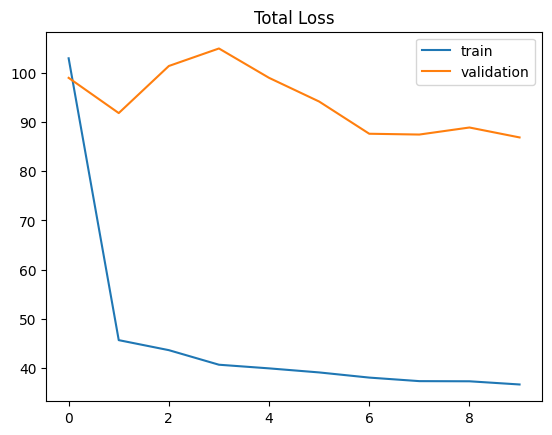

In [18]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Total Loss')
plt.legend()
plt.show()

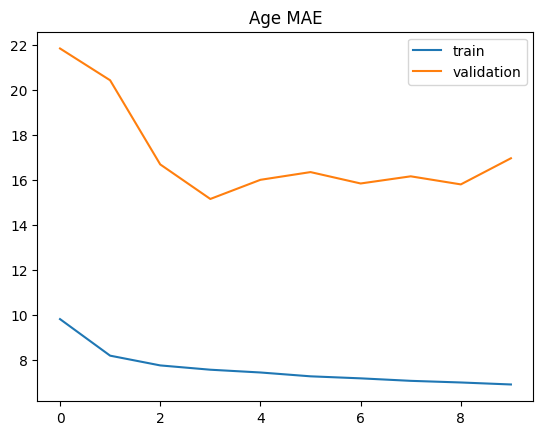

In [19]:
plt.plot(history.history['age_mae'], label='train')
plt.plot(history.history['val_age_mae'], label='validation')
plt.title('Age MAE')
plt.legend()
plt.show()

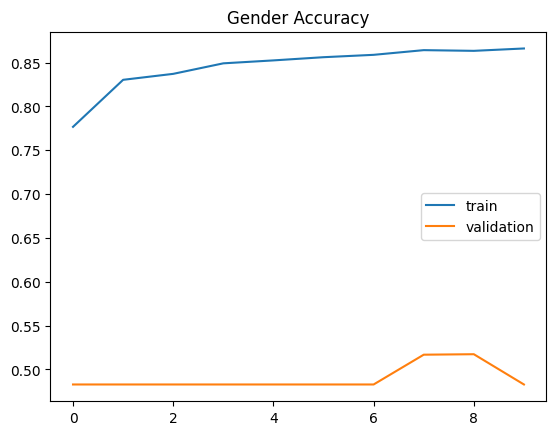

In [20]:
plt.plot(history.history['gender_accuracy'], label='train')
plt.plot(history.history['val_gender_accuracy'], label='validation')
plt.title('Gender Accuracy')
plt.legend()
plt.show()

In [21]:
# complete prediction function
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.utils import load_img
def predict_age_gender(image_path):
    img = load_img(image_path, target_size=(200, 200))
    img = img_to_array(img)

    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    age_pred, gender_pred = model.predict(img, verbose=0)

    age = round(age_pred[0][0])

    gender = "Male" if gender_pred[0][0] > 0.5 else "Female"

    return age, gender

In [22]:
train_df['gender'].value_counts()

0    10473
1     9527
Name: gender, dtype: int64

In [23]:
# gender branch -> issue

In [24]:
model.save("age_gender_model.keras")

In [25]:
model.save_weights("age_gender_weights.h5")

In [26]:
x, y = next(train_generator)

print(type(y))
print(len(y))

print(y[0][:10])  # age
print(y[1][:10])  # gender

<class 'list'>
2
[28 38 65 20 50 26 50 75 39  2]
[1 1 0 0 1 0 1 0 0 1]


In [27]:
x, y = next(train_generator)

age_pred, gender_pred = model.predict(x[:32])

print(gender_pred[:20])

1/1 [==============================] - 1s 771ms/step
[[8.1651270e-01]
 [8.9333141e-01]
 [9.7314024e-01]
 [4.0976030e-01]
 [2.0070493e-01]
 [2.3832779e-01]
 [3.2596401e-04]
 [1.6903549e-01]
 [7.9260832e-01]
 [1.4704233e-01]
 [6.0647293e-03]
 [1.7475294e-01]
 [7.3338997e-05]
 [6.4693997e-03]
 [6.3010329e-01]
 [8.0983825e-02]
 [9.9422932e-01]
 [1.4797626e-04]
 [7.0914879e-02]
 [2.1186542e-02]]
